# 05 · Explainability, errors and operational policy

**Validation only.** The primary is the existing uncalibrated logistic model. No tuning, new features or test access is permitted here. The 10% capacity is an explicit portfolio scenario, not measured hospital staffing. Scores occur at confirmed discharge after destination is known.

This notebook verifies cached development artifacts, recomputes validation aggregates, and checks technically valid SHAP explanations. The original frozen test is not parsed. Final model inference happens through a separate, committed-protocol-gated command; notebook 06 reviews the archived result.

In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("NUMBA_CACHE_DIR", ".cache/numba")
# SHAP's legacy plotting helpers emit these unrelated import-time notices.
warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module=r"shap\.plots.*")
warnings.filterwarnings("ignore", message="IProgress not found.*", module=r"tqdm.*")

from IPython.display import Image, Markdown, display
from readmit_iq.decision_support.plots import read_table, generate_figures

root = Path.cwd()
assert (root / "configs/phase5.yaml").exists()


In [2]:
from readmit_iq.decision_support.validation import run
summary = run()
assert summary["partition"] == "validation"
assert summary["model_refitted"] is False
record = json.loads((root / "reports/modeling/phase5/validation/development_record.json").read_text())
assert record["test_records_loaded"] is False
print("Frozen development models verified; zero test records loaded.")

{
  "primary": "logistic__uncalibrated",
  "policy": 0.1,
  "validation_metrics": [
    {
      "encounters": 13590,
      "patients": 9757,
      "positives": 1499,
      "prevalence": 0.11030169242089771,
      "mean_probability": 0.10914096393588614,
      "targeted_encounters": 1359,
      "targeted_patients": 871,
      "fraction_targeted": 0.1,
      "recall": 0.2141427618412275,
      "precision": 0.23620309050772628,
      "specificity": 0.9141510214208916,
      "tp": 321,
      "fp": 1038,
      "fn": 1178,
      "tn": 11053,
      "lift": 2.141427618412275,
      "number_needed_to_contact": 4.233644859813084,
      "random_expected_captured": 149.89999999999998,
      "additional_captured": 171.10000000000002,
      "average_precision": 0.1967806996565404,
      "roc_auc": 0.6545928752766503,
      "brier": 0.09506498716653106,
      "model": "logistic__uncalibrated",
      "partition": "validation",
      "capacity": 0.1,
      "realized_cutoff": 0.169407398007815
    },
  

## Tradeoffs determine a capacity scenario

Top 5% has higher precision but captures only 13.3% of validation readmissions. Top 10% captures 21.4% at 23.6% precision; top 15% captures 28.4% at 20.9% precision. Ten percent is an understandable limited-outreach illustration, not an optimum supported by cost or benefit evidence. The same fraction and outcome-independent tie rule will be frozen before test.

Select `floor(0.10*N)` discharge encounters, rank by decreasing probability, and break ties by SHA-256 of `42:<encounter_id>`. Report deduplicated historical people separately; this extract cannot measure concurrent or daily workload.

In [3]:
capacity = read_table(root, "validation", "capacity", True)
display(capacity[["capacity", "cutoff", "targeted_encounters", "targeted_patients", "tp", "fn", "recall", "precision", "lift"]])
display(read_table(root, "validation", "logistic__uncalibrated_thresholds")[["threshold", "fraction_targeted", "targeted_encounters", "targeted_patients", "recall", "precision", "fp", "fn", "number_needed_to_contact"]])

,capacity,cutoff,targeted_encounters,targeted_patients,tp,fn,recall,precision,lift
0,0.05,0.222039,679,440,199,1300,0.132755,0.293078,2.657059
1,0.10,0.169407,1359,871,321,1178,0.214143,0.236203,2.141428
2,0.15,0.143096,2038,1281,425,1074,0.283522,0.208538,1.890613
3,0.20,0.130803,2718,1732,538,961,0.358906,0.197940,1.794530
4,0.25,0.121793,3397,2176,641,858,0.427618,0.188696,1.710725


,threshold,fraction_targeted,targeted_encounters,targeted_patients,recall,precision,fp,fn,number_needed_to_contact
0,0.050000,0.984327,13377,9577,0.995330,0.111535,11885,7,8.965818
1,0.100000,0.410155,5574,3608,0.606404,0.163079,4665,590,6.132013
2,0.150000,0.134143,1823,1144,0.267512,0.219967,1422,1098,4.546135
3,0.169407,0.100000,1359,871,0.214143,0.236203,1038,1178,4.233645
4,0.200000,0.066667,906,588,0.162108,0.268212,663,1256,3.728395
5,0.250000,0.035467,482,298,0.100067,0.311203,332,1349,3.213333
6,0.300000,0.018617,253,142,0.056704,0.335968,168,1414,2.976471
7,0.500000,0.002281,31,14,0.006671,0.322581,21,1489,3.100000


In [4]:
deciles = read_table(root, "validation", "risk_deciles", True)
assert deciles.encounters.sum() == 13590 and deciles.positives.sum() == 1499
display(deciles.drop(columns=["model", "partition"]))
display(summary["scenario"])

,risk_group,encounters,patients,positives,observed_rate,mean_probability,cumulative_targeted,population_fraction,cumulative_captured,cumulative_recall,group_lift,cumulative_lift
0,1,1359,871,321,0.236203,0.249182,1359,0.1,321,0.214143,2.141428,2.141428
1,2,1359,1166,217,0.159676,0.145717,2718,0.2,538,0.358906,1.447632,1.794530
2,3,1359,1260,189,0.139073,0.121663,4077,0.3,727,0.484990,1.260841,1.616633
3,4,1359,1290,170,0.125092,0.106826,5436,0.4,897,0.598399,1.134089,1.495997
4,5,1359,1303,158,0.116262,0.095442,6795,0.5,1055,0.703803,1.054036,1.407605
5,6,1359,1322,117,0.086093,0.087005,8154,0.6,1172,0.781855,0.780520,1.303091
6,7,1359,1335,98,0.072112,0.081781,9513,0.7,1270,0.847231,0.653769,1.210331
7,8,1359,1329,85,0.062546,0.076217,10872,0.8,1355,0.903936,0.567045,1.129920
8,9,1359,1333,79,0.058131,0.069967,12231,0.9,1434,0.956638,0.527018,1.062931
9,10,1359,1327,65,0.047829,0.057610,13590,1.0,1499,1.000000,0.433622,1.000000


{'scenario': 'Illustrative operational scenario; capacity is a portfolio assumption',
 'eligible_discharges': 10000,
 'expected_observed_readmissions': 1103.0169242089771,
 'outreach_encounters': 1000.0,
 'model_surfaced_readmissions': 236.20309050772627,
 'random_surfaced_readmissions': 110.30169242089771,
 'additional_surfaced_readmissions': 125.90139808682856,
 'number_needed_to_contact': 4.233644859813084,
 'prevention_effect_estimated': False,
 'unique_people_scaled': False}

## What drives the frozen scores?

Coefficients use original numeric units, and categorical odds ratios compare explicit within-field reference levels. Prior inpatient use and discharge destination dominate. One extra prior inpatient visit multiplies modeled odds by 1.314, holding other modeled fields fixed; this is an association, not an intervention effect.

Linear SHAP explains all validation rows. The native-categorical booster's TreeSHAP adapter fails an actual-output check, so the comparison uses permutation SHAP of its real decision function on 256 matched validation rows, with 128 training background rows. Independent masking and finite background/permutation sampling limit interpretation. Small outpatient effects disagree in direction; neither is claimed causal.

In [5]:
coefficients = read_table(root, "validation", "coefficient_contrasts")
display(coefficients.loc[coefficients.feature.isin(["number_inpatient", "number_emergency", "number_outpatient", "time_in_hospital"]), ["feature", "coefficient", "odds_ratio", "training_scale"]])
checks = json.loads((root / "reports/modeling/phase5/validation/explanation_verification.json").read_text())
display({key: checks[key] for key in ["linear_method", "boosting_method", "tree_adapter_check", "logistic_maximum_additivity_error", "boosting_maximum_additivity_error"]})
display(read_table(root, "validation", "explanation_direction_checks"))

,feature,coefficient,odds_ratio,training_scale
0,time_in_hospital,0.013326,1.013415,2.920930
1,number_inpatient,0.273212,1.314179,1.287858
2,number_emergency,0.040756,1.041598,0.997629
3,number_outpatient,-0.003097,0.996908,1.322313


{'linear_method': 'LinearExplainer, independent training background, grouped one-hot sums',
 'boosting_method': 'PermutationExplainer of actual categorical decision_function',
 'tree_adapter_check': {'accepted': False,
  'maximum_log_odds_error': 2.539238810418192,
  'rows_checked': 32},
 'logistic_maximum_additivity_error': 1.1102230246251565e-15,
 'boosting_maximum_additivity_error': 7.993605777301127e-15}

,feature,logistic_coefficient_per_unit,logistic_shap_rank_association,boosting_shap_rank_association
0,time_in_hospital,0.013326,1.0,0.940882
1,number_inpatient,0.273212,1.0,0.836695
2,number_emergency,0.040756,1.0,0.535869
3,number_outpatient,-0.003097,-1.0,0.353379


## Errors: limited history is a major blind spot

779/1,499 readmissions (52.0%) have no prior inpatient use. The selected policy captures only 47 (6.0%), versus 274/720 (38.1%) with prior use. The 732 missed low-utilization readmissions represent 62.1% of all false negatives. Most have no prior emergency use; their discharge destinations are primarily home, skilled nursing and home health. Of the 47 captured low-utilization readmissions, 46 have rehabilitation destination code 22.

These findings expose care-setting and history dependence. The current allowed features already identify some exceptions, but the fixed booster captures only 45 low-utilization events. New diagnoses/labs are not added. Fragmented history or missing acute/social information are plausible dataset limitations, not established causes.

In [6]:
display(read_table(root, "validation", "error_profiles", True).drop(columns=["model", "partition"]))
detail = read_table(root, "validation", "error_characteristics", True)
display(detail.loc[detail.group.eq("discharge_destination")].drop(columns=["model", "partition"]))

,cohort,encounters,patients,mean_probability,median_stay,no_prior_inpatient_fraction,no_prior_emergency_fraction
0,all_readmissions,1499,1190,0.139315,4.0,0.519680,0.842562
1,false_negative,1178,1038,0.103582,4.0,0.621392,0.858234
2,false_positive,1038,755,0.242606,5.0,0.151252,0.718690
3,low_utilization_false_negative,732,725,0.091723,4.0,1.000000,0.915301
4,low_utilization_true_positive,47,47,0.238885,4.0,1.000000,0.978723


,cohort,group,level,encounters,fraction
87,all_readmissions,discharge_destination,1,822,0.548366
88,all_readmissions,discharge_destination,3,304,0.202802
89,all_readmissions,discharge_destination,6,258,0.172115
90,all_readmissions,discharge_destination,22,76,0.050700
91,all_readmissions,discharge_destination,7,19,0.012675
92,all_readmissions,discharge_destination,4,18,0.012008
93,all_readmissions,discharge_destination,8,2,0.001334
94,false_negative,discharge_destination,1,715,0.606961
95,false_negative,discharge_destination,3,225,0.191002
96,false_negative,discharge_destination,6,206,0.174873


## Responsible ML and probability alignment

Keep counts/Unknown categories; suppress performance below 200 encounters, 100 patients, 30 positive or 30 negative labels. Recall/precision/prevalence/bias intervals respect patient clustering. Group intervals condition on the selected list; overall bootstrap intervals rerank the fixed capacity in each patient resample.

No major supported validation group meets the declared probability-bias flag (absolute mean error ≥2 percentage points with an interval excluding zero). Mean alignment does not establish within-group calibration or fairness. The prior-use recall gap is much larger than observed gender differences. Race is audit-only. Small demographic groups and wide intervals limit comparisons; no group-specific calibration or thresholds are fitted.

In [7]:
groups = read_table(root, "validation", "subgroups", True)
display(groups.loc[groups.group.isin(["prior_inpatient", "gender", "race"]), ["group", "level", "encounters", "positives", "suppressed", "prevalence", "recall", "recall_ci_low", "recall_ci_high", "precision", "probability_bias"]])
display(read_table(root, "validation", "metric_intervals", True))

,group,level,encounters,positives,suppressed,prevalence,recall,recall_ci_low,recall_ci_high,precision,probability_bias
0,prior_inpatient,Any,4456,720,False,0.161580,0.380556,0.337497,0.423614,0.237229,-0.008750
1,prior_inpatient,None,9134,779,False,0.085286,0.060334,0.043603,0.077065,0.230392,0.002542
16,gender,Female,7376,816,False,0.110629,0.207108,0.170283,0.243933,0.222955,-0.001565
17,gender,Male,6214,683,False,0.109913,0.222548,0.183923,0.261173,0.252912,-0.000681
18,race,AfricanAmerican,2599,254,False,0.097730,0.161417,0.099536,0.223298,0.161417,0.008820
19,race,Asian,100,8,True,NaN,NaN,NaN,NaN,NaN,NaN
20,race,Caucasian,10062,1154,False,0.114689,0.232236,0.201301,0.263171,0.256459,-0.003961
21,race,Hispanic,320,36,False,0.112500,0.138889,0.006317,0.271461,0.227273,-0.008406
22,race,Other,193,20,True,NaN,NaN,NaN,NaN,NaN,NaN
23,race,Unknown,316,27,True,NaN,NaN,NaN,NaN,NaN,NaN


,model,metric,ci_low,ci_high,valid_replicates
6,logistic__uncalibrated,average_precision,0.180294,0.217710,1000
7,logistic__uncalibrated,roc_auc,0.640330,0.669625,1000
8,logistic__uncalibrated,brier,0.090968,0.099298,1000
9,logistic__uncalibrated,recall,0.194019,0.235336,1000
10,logistic__uncalibrated,precision,0.210986,0.264751,1000
11,logistic__uncalibrated,lift,1.940482,2.353540,1000


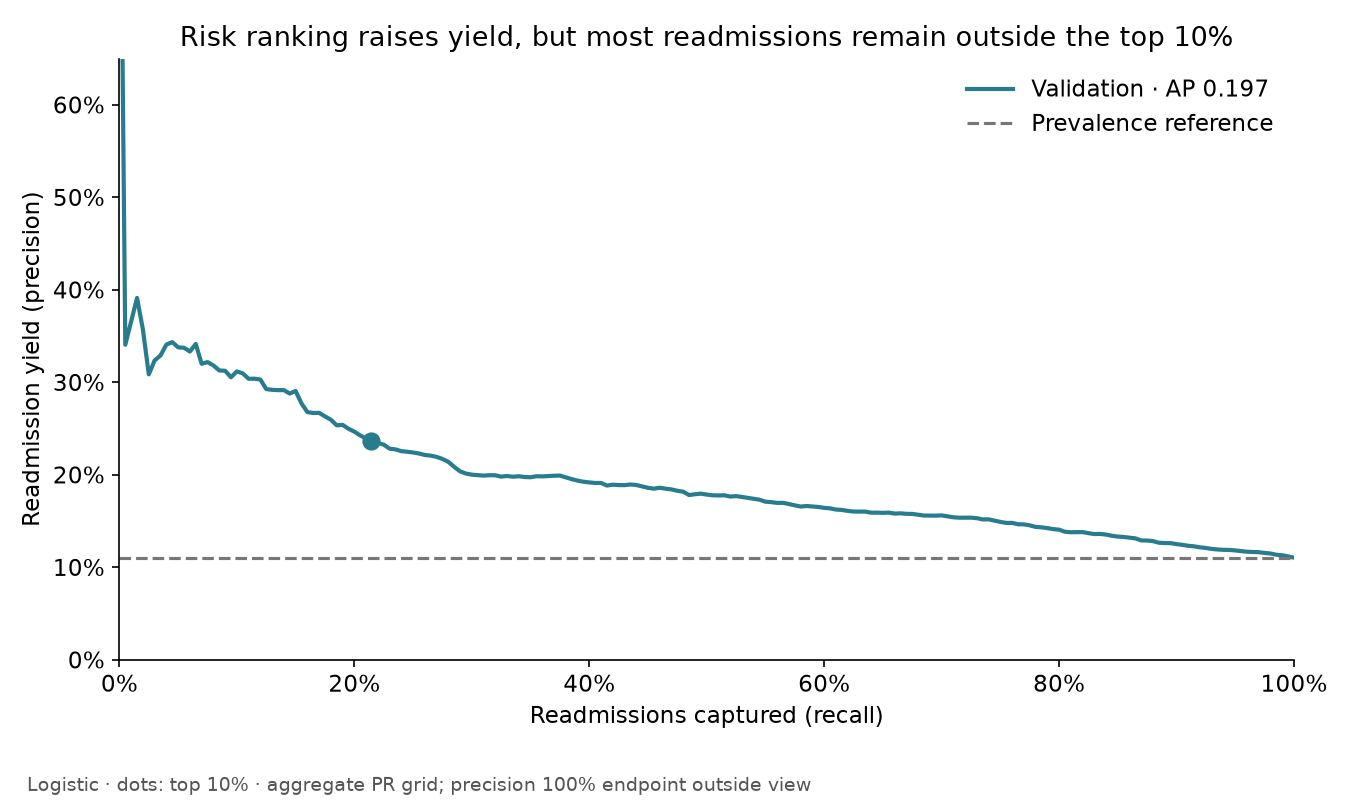

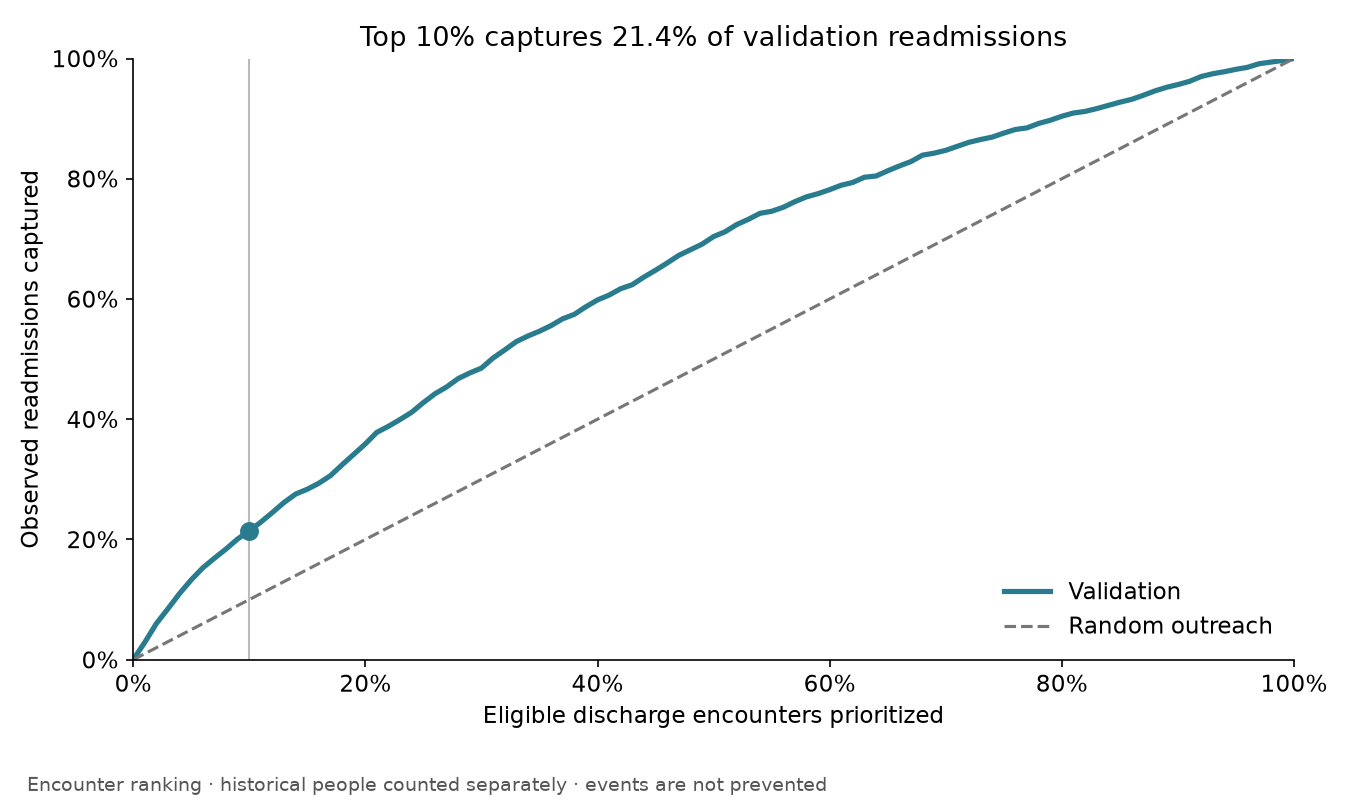

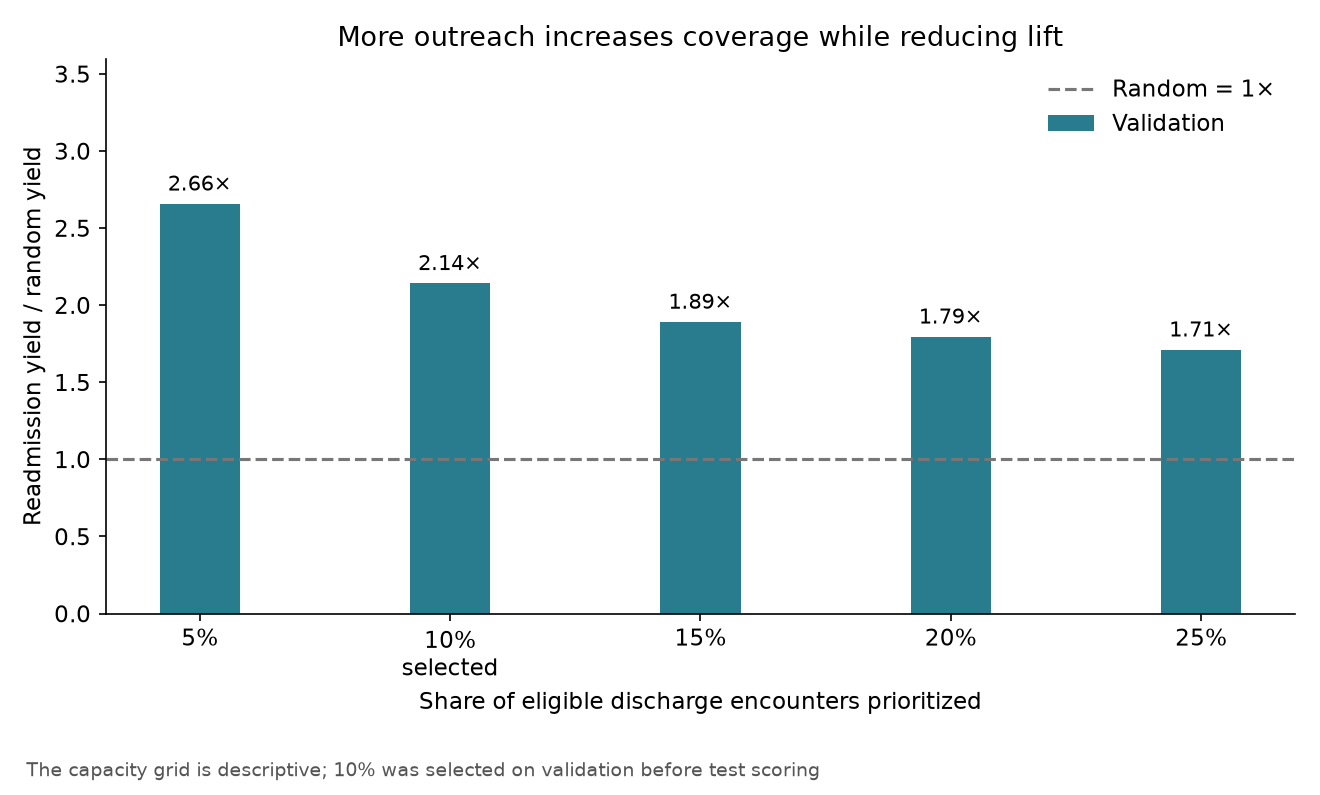

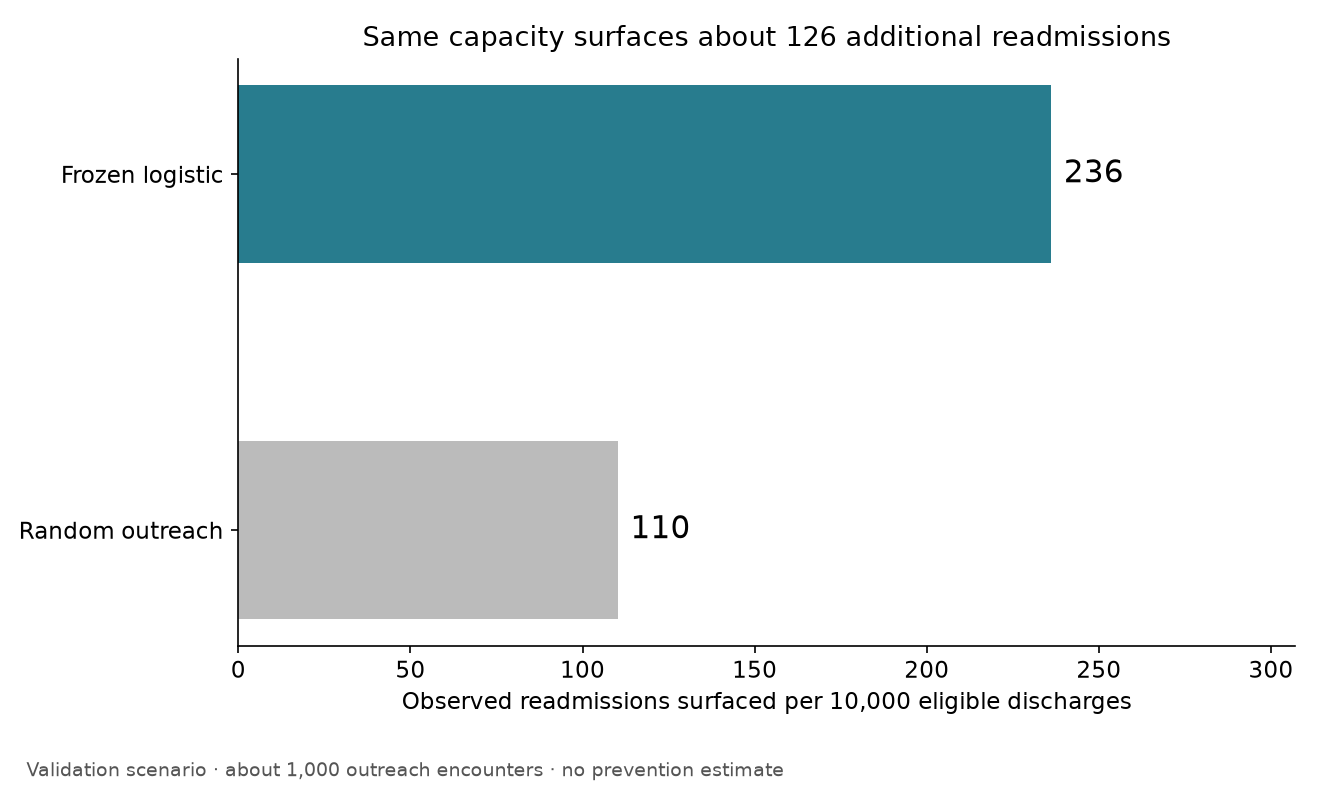

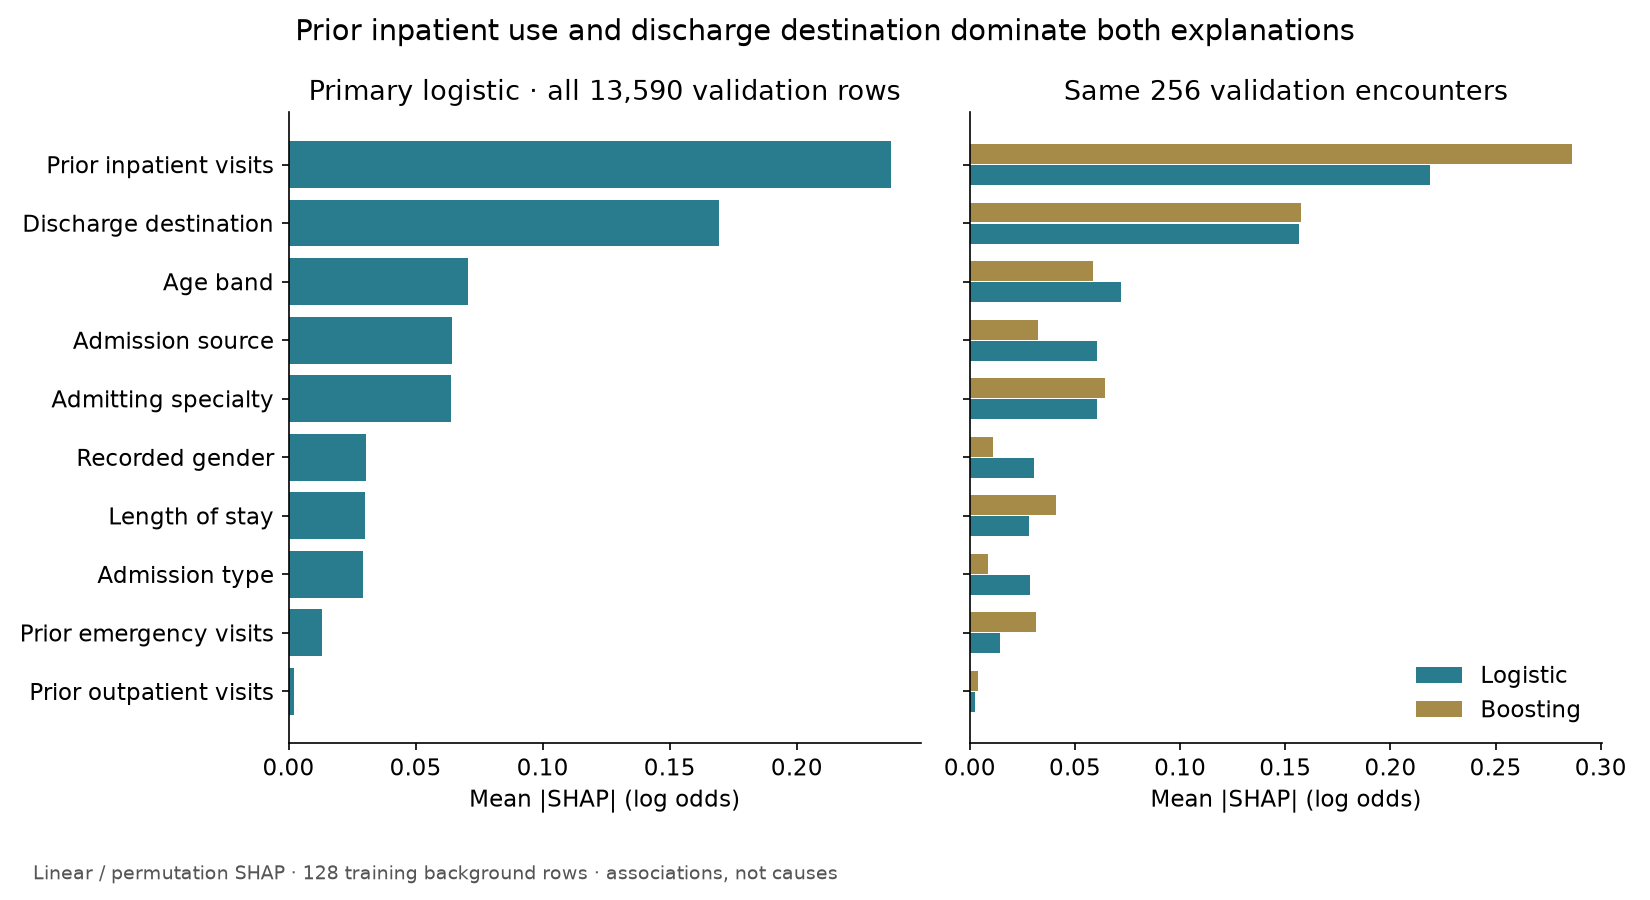

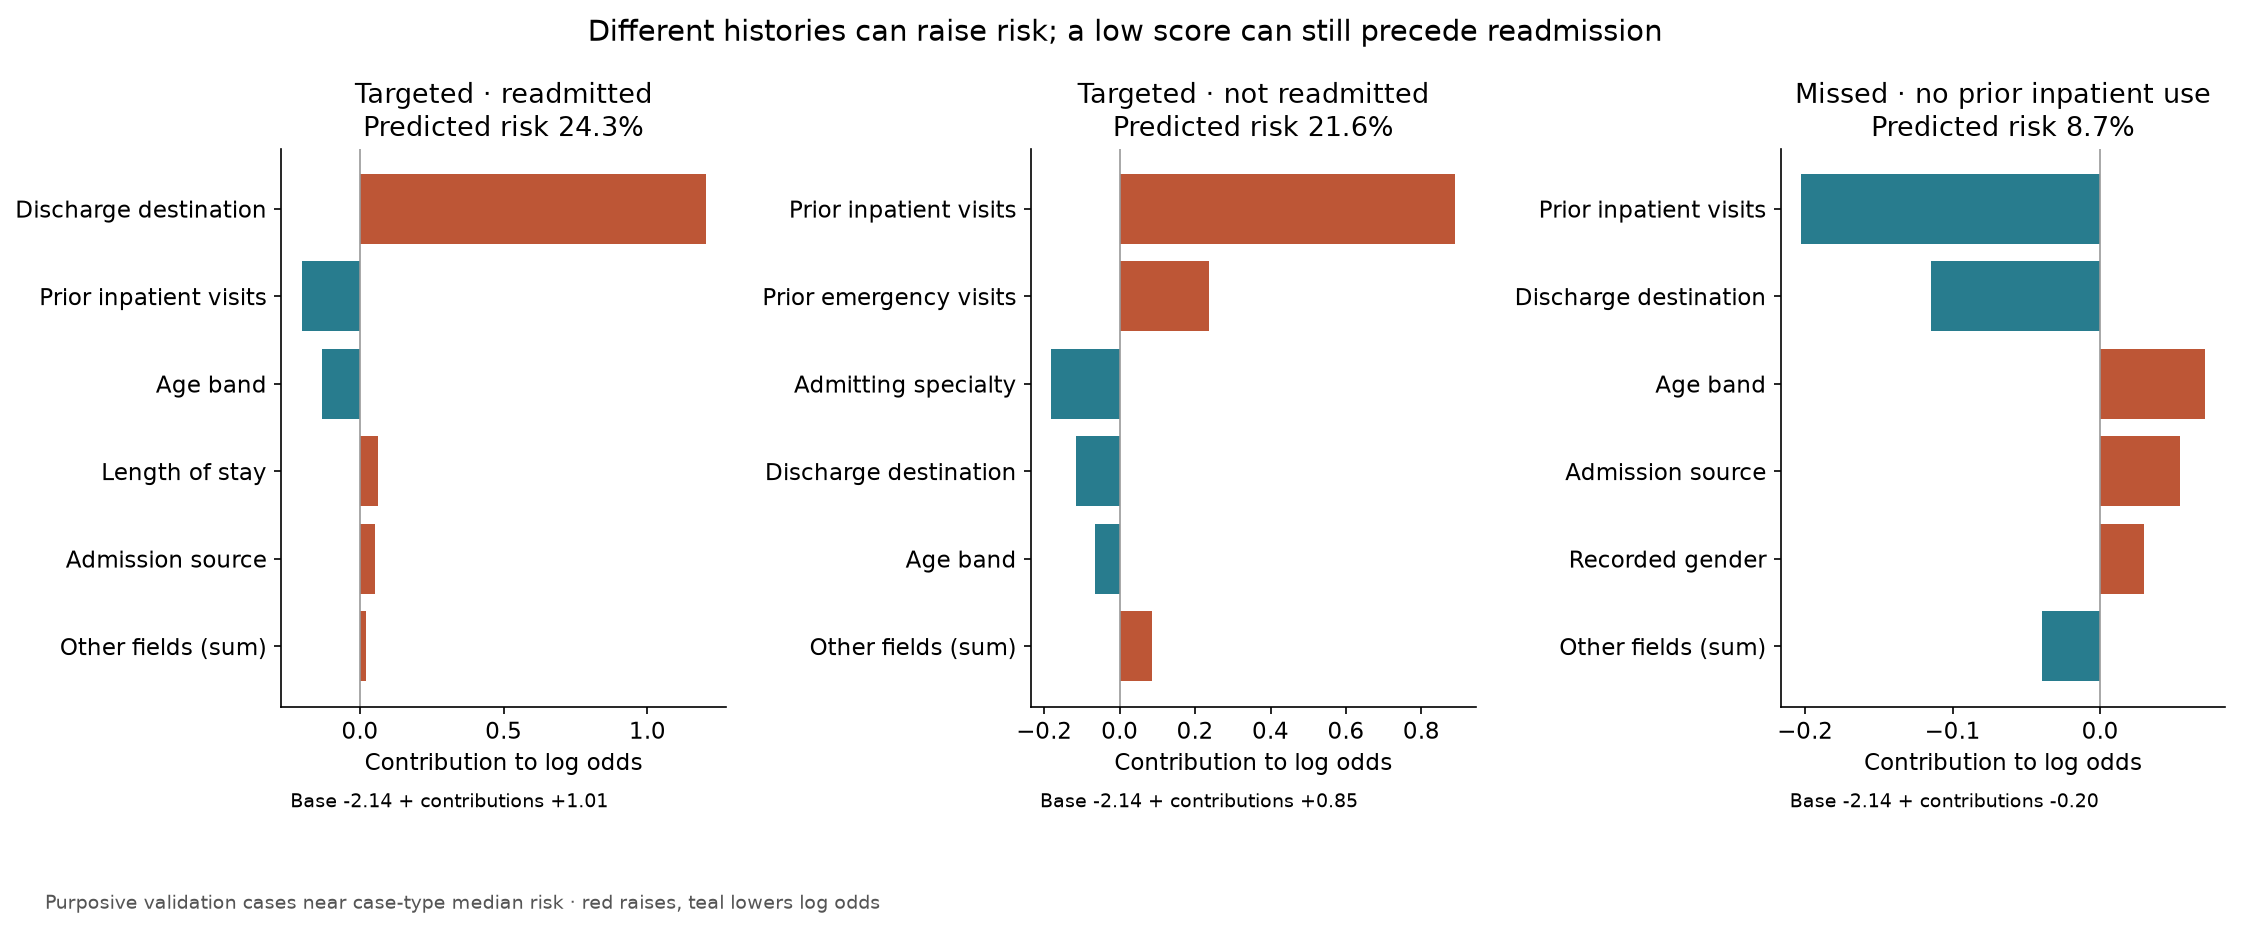

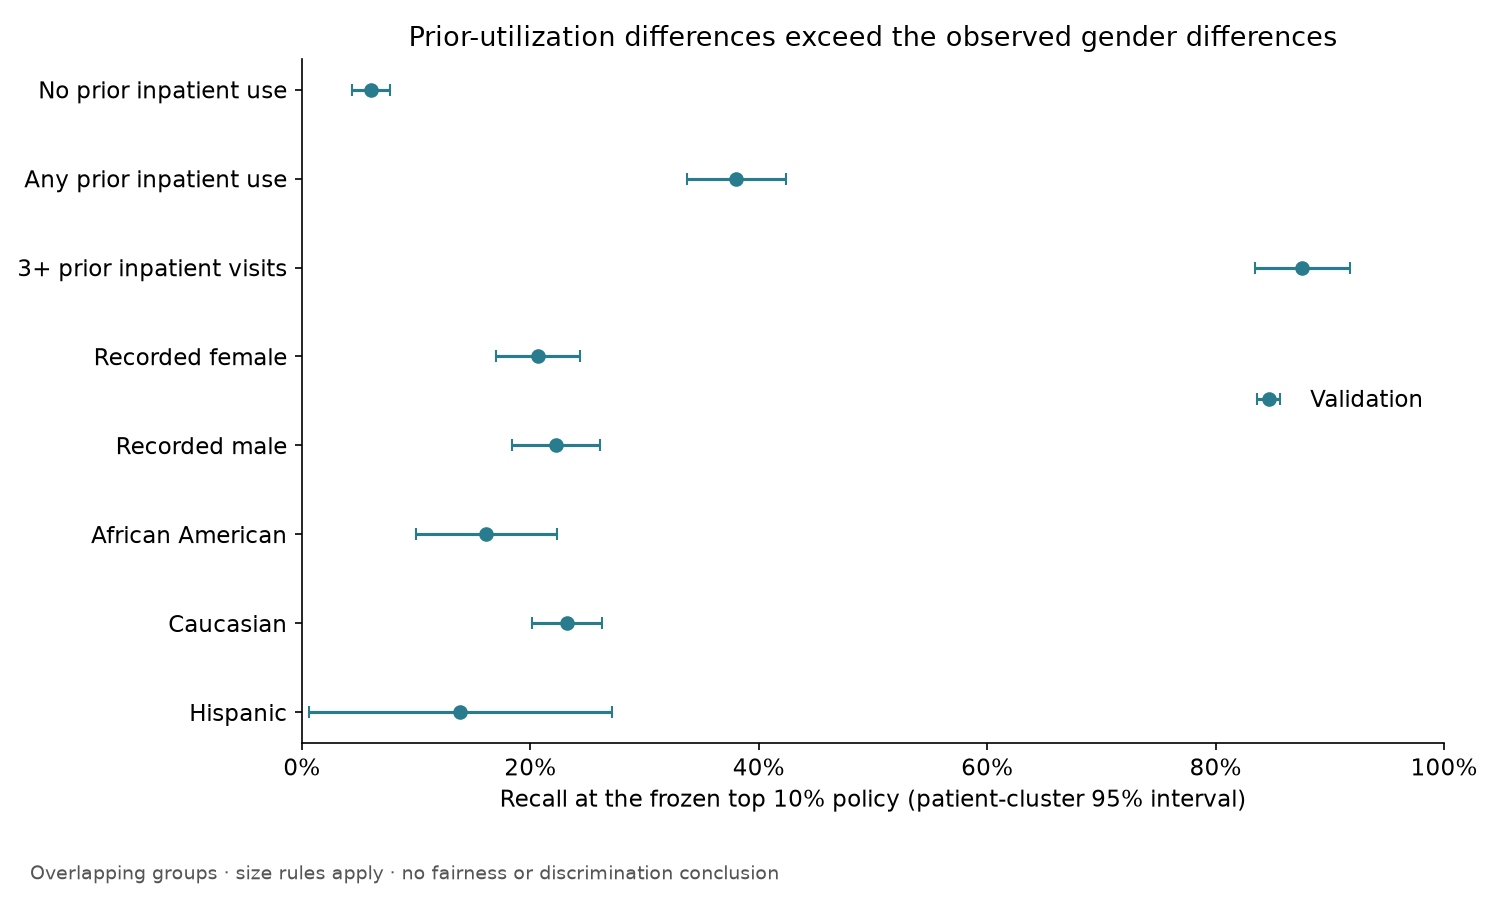

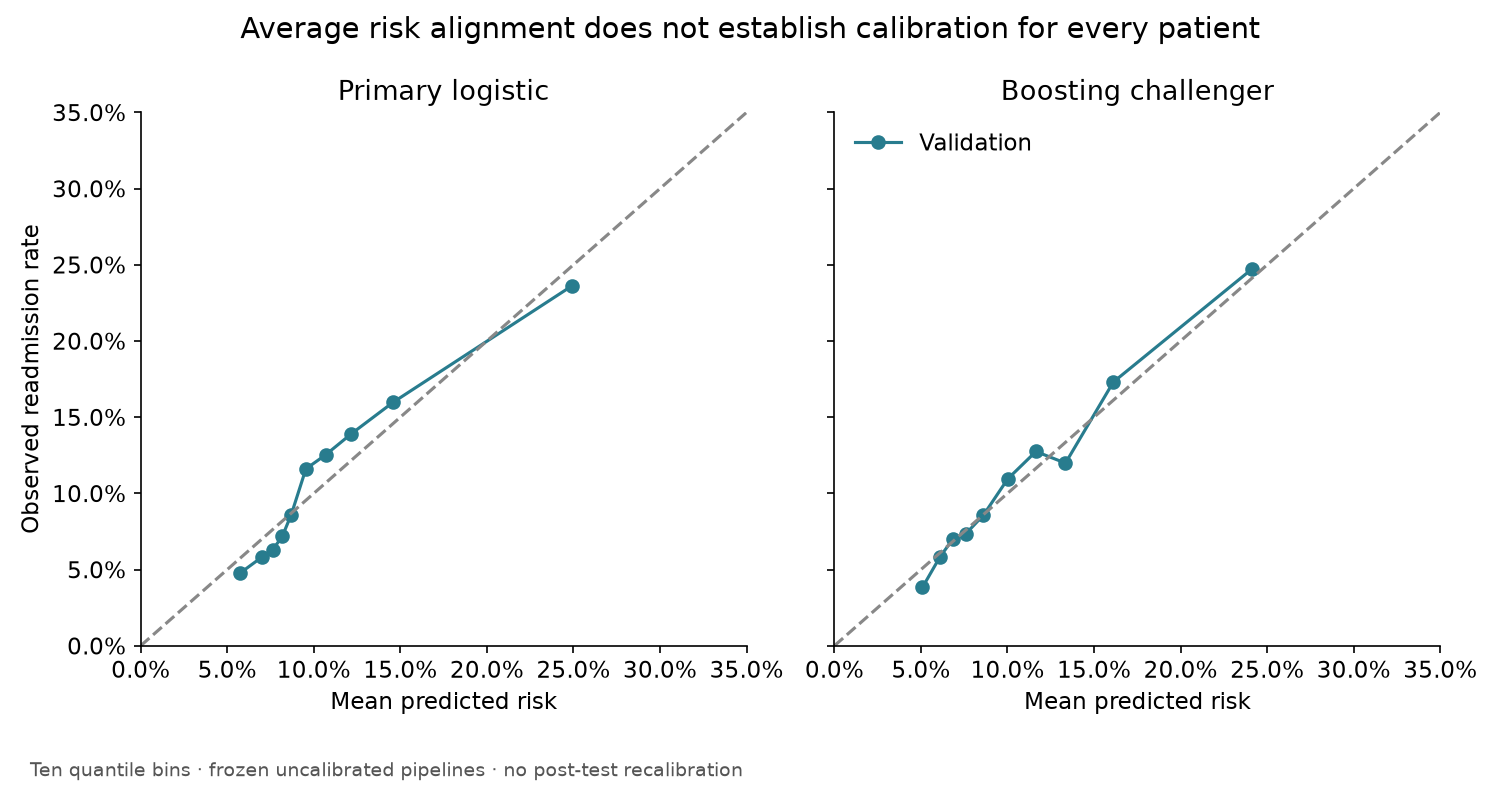

In [8]:
# This notebook always creates VALIDATION figures in an ignored directory.
# It cannot overwrite the final validation/test figures or read archived test results.
figures = generate_figures(root, root / ".cache/phase5-validation-figures", include_test=False)
assert len(figures) == 8
for path in figures:
    display(Image(filename=str(path)))

## Frozen decision and next boundary

The primary remains uncalibrated logistic, raw counts plus the ten approved discharge-time fields, L2/lbfgs, C=0.09988151348099303, trained only on the original 63,563 encounters. The challenger remains the fixed uncalibrated histogram booster. No train+validation refit, new feature, calibration or clinical benefit claim is made.

The formal specification and policy must be committed before the explicit `make final-eval` command. Once scored, local reanalysis uses verified ignored predictions; archived aggregate outputs support repeatable notebook/CI review without another real test prediction pass. Earlier full-cohort EDA exposed eventual test outcomes indirectly, so this is a held-out model evaluation rather than a fully untouched confirmatory study.

Read the [explanation report](../reports/modeling/explainability_report.md), [error analysis](../reports/modeling/validation_error_analysis.md), [policy report](../reports/modeling/operational_policy_report.md), [feature policy](../reports/modeling/final_feature_policy.md) and [responsible ML report](../reports/responsible_ml.md).